In [40]:
# Disease Detection Model

In [14]:
# Install Libraries
!pip install tensorflow pillow opencv-python matplotlib seaborn

In [16]:
# Import Libraries
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import files

In [4]:
# Upload Dataset
uploaded = files.upload()

Saving Tomato.zip to Tomato.zip


In [17]:
# Extract Dataset
with zipfile.ZipFile("Tomato.zip","r") as zip_ref:
    zip_ref.extractall("tomato_dataset")

In [18]:
# Check folder structure
os.listdir("tomato_dataset")

['Tomato']

In [28]:
# Data Image Generators
IMG_SIZE = 224
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

In [29]:
# Load Training data
train_data = train_datagen.flow_from_directory(
    "tomato_dataset/Tomato/Train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 10000 images belonging to 10 classes.


In [31]:
# Load Validation Dataset
val_data = val_datagen.flow_from_directory(
    "tomato_dataset/Tomato/Val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

Found 1000 images belonging to 10 classes.


In [32]:
# Verify Dataset
print("Classes:", train_data.class_indices)
print("Number of classes:", train_data.num_classes)
print("Training samples:", train_data.samples)
print("Validation samples:", val_data.samples)

Classes: {'Tomato Bacterial Spot': 0, 'Tomato Early Blight': 1, 'Tomato Healthy': 2, 'Tomato Late Blight': 3, 'Tomato Leaf Mold': 4, 'Tomato Mosaic Virus': 5, 'Tomato Septoria Leaf Spot': 6, 'Tomato Spider Mites': 7, 'Tomato Target Spot': 8, 'Tomato Yellow Leaf Curl Virus': 9}
Number of classes: 10
Training samples: 10000
Validation samples: 1000


In [33]:
# CNN Model
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Input(shape=(224,224,3)),
    layers.Conv2D(32,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(256,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(512,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes,activation='softmax')
])

In [34]:
# View model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,086,090 (99.51 MB)

 Trainable params: 26,085,130 (99.51 MB)

 Non-trainable params: 960 (3.75 KB)

In [35]:
# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [36]:
# Add Training Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    "best_tomato_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [38]:
# Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6737 - loss: 1.0643

313/313 ━━━━━━━━━━━━━━━━━━━━ 2150s 7s/step - accuracy: 0.6737 - loss: 1.0642 - val_accuracy: 0.4170 - val_loss: 3.5839 - learning_rate: 3.0000e-04
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7150 - loss: 0.8925

313/313 ━━━━━━━━━━━━━━━━━━━━ 2148s 7s/step - accuracy: 0.7150 - loss: 0.8925 - val_accuracy: 0.6080 - val_loss: 3.2884 - learning_rate: 3.0000e-04
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7720 - loss: 0.7355

313/313 ━━━━━━━━━━━━━━━━━━━━ 2150s 7s/step - accuracy: 0.7720 - loss: 0.7355 - val_accuracy: 0.6550 - val_loss: 2.1107 - learning_rate: 3.0000e-04
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7808 - loss: 0.7175

313/313 ━━━━━━━━━━━━━━━━━━━━ 2157s 7s/step - accuracy: 0.7808 - loss: 0.7175 - val_accuracy: 0.6560 - val_loss: 2.6556 - learning_rate: 3.0000e-04
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7957 - loss: 0.6241

313/313 ━━━━━━━━━━━━━━━━━━━━ 2158s 7s/step - accuracy: 0.7957 - loss: 0.6240 - val_accuracy: 0.8330 - val_loss: 0.6779 - learning_rate: 3.0000e-04
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2189s 7s/step - accuracy: 0.8141 - loss: 0.5736 - val_accuracy: 0.6950 - val_loss: 3.4166 - learning_rate: 3.0000e-04
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2116s 7s/step - accuracy: 0.8303 - loss: 0.5124 - val_accuracy: 0.7720 - val_loss: 1.6177 - learning_rate: 3.0000e-04
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2104s 7s/step - accuracy: 0.8383 - loss: 0.5166 - val_accuracy: 0.8190 - val_loss: 1.0361 - learning_rate: 3.0000e-04
Epoch 9/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2119s 7s/step - accuracy: 0.8768 - loss: 0.3716 - val_accuracy: 0.7470 - val_loss: 2.8116 - learning_rate: 9.0000e-05
Epoch 10/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2242s 7s/step - accuracy: 0.8942 - loss: 0.3189 - val_accuracy: 0.8210 - val_loss: 1.3419 - learning_rate: 9.0000e-05


In [42]:
# Evaluation
val_loss, val_accuracy = model.evaluate(val_data)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8298 - loss: 0.7012
Validation Loss: 0.6778966784477234
Validation Accuracy: 0.8330000042915344


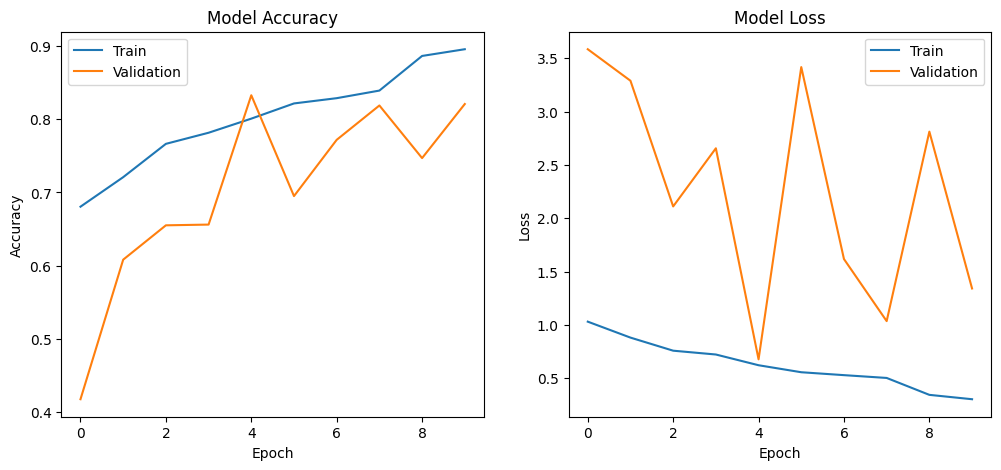

In [43]:
# Plot Training Curves
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

In [44]:
# Predictions on Validation Dataset
import numpy as np
val_data.reset()
predictions = model.predict(val_data)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_data.classes

32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step


In [45]:
#Class Labels
class_labels = list(val_data.class_indices.keys())
print(class_labels)

['Tomato Bacterial Spot', 'Tomato Early Blight', 'Tomato Healthy', 'Tomato Late Blight', 'Tomato Leaf Mold', 'Tomato Mosaic Virus', 'Tomato Septoria Leaf Spot', 'Tomato Spider Mites', 'Tomato Target Spot', 'Tomato Yellow Leaf Curl Virus']


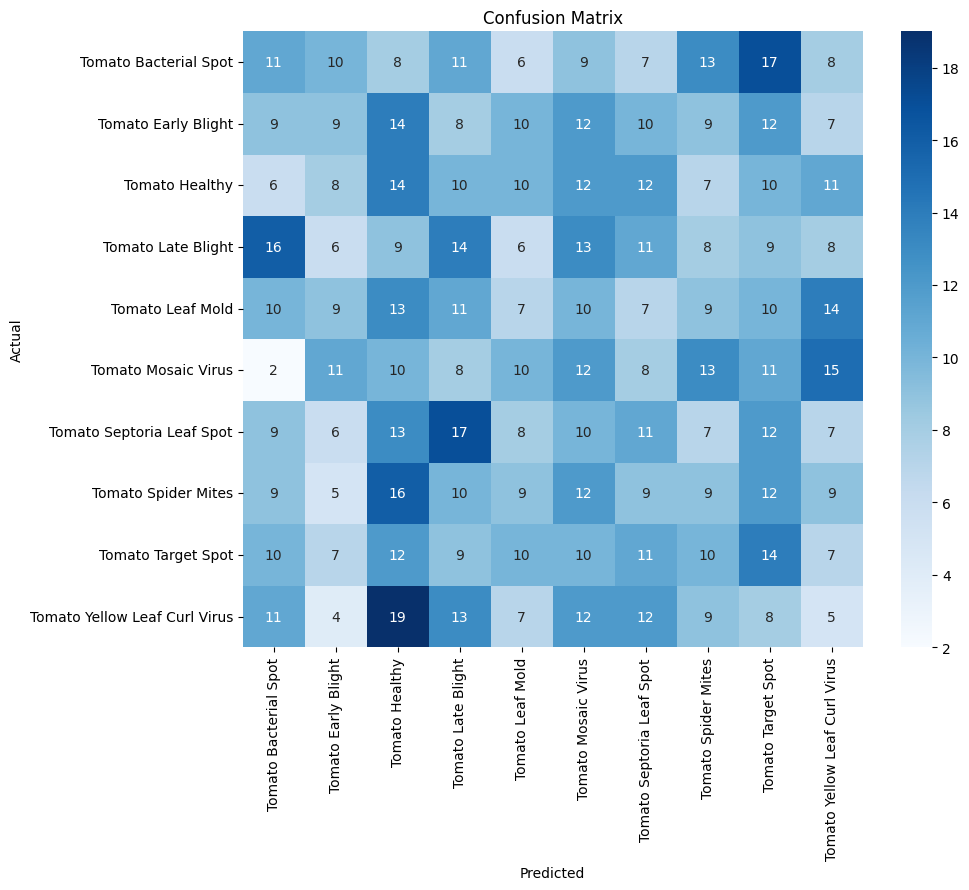

In [47]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [41]:
# Save Final Model and Download
model.save("tomato_disease_model.keras")
from google.colab import files
files.download("tomato_disease_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>